In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from start import StockDataManager

In [5]:




class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.layers = nn.ModuleList()
    
    def layer_maker(self, type, input_size, hidden_size, num_layers):
        if type == 'LSTM':
            return nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        elif type == 'GRU':
            return nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        elif type == 'RNN':
            return nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        elif type == 'linear':
            return nn.Linear(input_size, hidden_size)
        else:
            raise ValueError(f"Unsupported layer type: {type}")
    
    def create(self, x, struct: list[dict]):
        self.validate_struct(struct, expected_input_size=x.size(-1))
        for layer in struct:
            self.layers.append(
                self.layer_maker(
                    type=layer["type"], 
                    input_size=layer["input_size"], 
                    hidden_size=layer.get("hidden_size"), 
                    num_layers=layer.get("num_layers")
                )
            )
        return struct, self.layers
    
    def validate_struct(self, struct: list[dict], expected_input_size: int):
        prev_output_size = expected_input_size

        for i, layer in enumerate(struct):
            required = {"type", "input_size", "output_size"}
            missing = required - layer.keys()
            if missing:
                raise ValueError(f"Layer {i} missing keys: {missing}")

            if layer["input_size"] != prev_output_size:
                raise ValueError(
                    f"Layer {i} input_size {layer['input_size']} "
                    f"does not match previous output_size {prev_output_size}"
                )

            if layer["type"] in {"LSTM", "GRU", "RNN"}:
                if "hidden_size" not in layer or "num_layers" not in layer:
                    raise ValueError(f"Layer {i} missing hidden_size or num_layers")

                if layer["output_size"] != layer["hidden_size"]:
                    raise ValueError(
                        f"Layer {i} output_size must equal hidden_size for RNN layers"
                    )

            prev_output_size = layer["output_size"]
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor (batch, seq_len, features)
        
        Returns:
            Output tensor (batch, 1)
        """
        sequence_collapsed = False
        
        for layer in self.layers:
            if isinstance(layer, (nn.LSTM, nn.GRU, nn.RNN)):
                x, _ = layer(x)
                
            elif isinstance(layer, nn.Linear):
                if not sequence_collapsed and x.dim() == 3:
                    x = x[:, -1, :]
                    sequence_collapsed = True
                
                x = layer(x)
        
        return x


# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_model(model, X_train, y_train, X_test=None, y_test=None, epochs=50, batch_size=32, lr=0.001):    
    """
    Train the LSTM model.
    
    Args:
        model: LSTM model to train
        X_train: Training input data
        y_train: Training target data
        X_test: Test input data (optional)
        y_test: Test target data (optional)
        epochs: Number of epochs
        batch_size: Batch size
        lr: Learning rate
    
    Returns:
        train_losses: List of training losses per epoch
        test_losses: List of test losses per epoch
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    num_batches = len(X_train) // batch_size
    
    print(f"\nTraining Configuration:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Learning rate: {lr}")
    print(f"  Batches per epoch: {num_batches}")
    print(f"  Training samples: {len(X_train)}")
    if X_test is not None:
        print(f"  Test samples: {len(X_test)}")
    print("=" * 70)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        # Shuffle training data
        indices = torch.randperm(len(X_train))
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        # Mini-batch training
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            
            batch_X = X_train_shuffled[start_idx:end_idx]
            batch_y = y_train_shuffled[start_idx:end_idx]
            
            # Forward pass
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Calculate average training loss
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # Evaluate on test set
        test_loss = None
        if X_test is not None and y_test is not None:
            model.eval()
            with torch.no_grad():
                test_predictions = model(X_test)
                test_loss = criterion(test_predictions, y_test).item()
                test_losses.append(test_loss)
        
        # Print progress
        if epochs <= 20 or (epoch + 1) % 5 == 0 or epoch == 0:
            if test_loss is not None:
                print(f"Epoch [{epoch+1:3d}/{epochs}] - Train Loss: {avg_train_loss:.4f} - Test Loss: {test_loss:.4f}")
            else:
                print(f"Epoch [{epoch+1:3d}/{epochs}] - Train Loss: {avg_train_loss:.4f}")
    
    print("=" * 70)
    print("Training Complete!")
    print(f"Final Train Loss: {train_losses[-1]:.4f}")
    if test_losses:
        print(f"Final Test Loss: {test_losses[-1]:.4f}")
    print("=" * 70)
    
    return train_losses, test_losses



def evaluate_predictions(model, X_test, y_test, mean_y, std_y, show_all=False):

    print("\n" + "="*70)
    print("TEST SET PREDICTIONS vs ACTUAL PRICES")
    print("="*70)
    
    # Make predictions
    model.eval()
    with torch.no_grad():
        test_predictions_norm = model(X_test)
    
    # Denormalize to get actual dollar prices
    predictions_actual = test_predictions_norm * std_y + mean_y
    targets_actual = y_test * std_y + mean_y
    
    # Calculate metrics
    differences = predictions_actual - targets_actual
    mae = differences.abs().mean().item()
    rmse = (differences ** 2).mean().sqrt().item()
    mape = (differences.abs() / targets_actual * 100).mean().item()
    
    print(f"\nTest Set Performance:")
    print(f"  Total samples: {len(X_test)}")
    print(f"  Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"  Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    
    # Determine how many to show
    num_to_show = len(predictions_actual) if show_all else min(20, len(predictions_actual))
    
    print(f"\n{'First ' + str(num_to_show) if not show_all else 'All ' + str(num_to_show)} Predictions:")
    print("-"*70)
    print(f"{'#':>4} | {'Predicted':>12} | {'Actual':>12} | {'Difference':>12} | {'Error %':>10}")
    print("-"*70)
    
    for i in range(num_to_show):
        pred = predictions_actual[i].item()
        actual = targets_actual[i].item()
        diff = pred - actual
        error_pct = abs(diff) / actual * 100
        
        print(f"{i+1:4d} | ${pred:11.2f} | ${actual:11.2f} | ${diff:+11.2f} | {error_pct:9.2f}%")
    
    if not show_all and len(predictions_actual) > num_to_show:
        print(f"  ... ({len(predictions_actual) - num_to_show} more samples)")
    
    print("-"*70)
    avg_diff = differences.mean().item()
    avg_error_pct = mape
    print(f"{'AVG':>4} | {'':>12} | {'':>12} | ${avg_diff:+11.2f} | {avg_error_pct:9.2f}%")
    print("="*70)


def plot_training_history(train_losses, test_losses):
    """Plot training and test loss over epochs."""
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Regular scale
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', alpha=0.7)
    plt.plot(test_losses, label='Test Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Log scale (better for seeing details)
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss', alpha=0.7)
    plt.plot(test_losses, label='Test Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training History (Log Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()




    
    
    
    

In [6]:
print("="*70)
print("LSTM STOCK PRICE PREDICTOR")
print("="*70)
    
# Step 1: Load or fetch data
print("\n1. Loading data...")
manager = StockDataManager(save_dir='stock_data')
    
data = manager.prepare_for_training(
    symbols=['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'AMZN'],
    seq_length=60,
    prediction_days=1,
    total_days=365,
    train_ratio=0.8,
    normalize=True,
    save=True
)

LSTM STOCK PRICE PREDICTOR

1. Loading data...
PREPARING STOCK DATA FOR TRAINING
Fetching data for 5 stocks...
Sequence length: 60, Total days: 365

Created 1145 training sequences
X shape: torch.Size([1145, 60, 5])
y shape: torch.Size([1145, 1, 1])

Normalizing data...
X normalized: mean=10345486.0000, std=6857477.0000
y normalized: mean=305.5341, std=111.6150

Data split:
  Training: 916 samples
  Testing: 229 samples

Data saved to stock_data\stock_data.pkl

DATA PREPARATION COMPLETE


In [18]:
    # Step 2: Extract data
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']
    
    # Fix y shapes if needed
y_train = y_train.squeeze()
y_test = y_test.squeeze()
    
if y_train.dim() == 1:
    y_train = y_train.unsqueeze(1)
if y_test.dim() == 1:
    y_test = y_test.unsqueeze(1)
print(f"Data shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
    

Data shapes:
  X_train: torch.Size([916, 60, 5])
  y_train: torch.Size([916, 1])
  X_test: torch.Size([229, 60, 5])
  y_test: torch.Size([229, 1])


In [21]:
print("\n2. Creating model...")
struct = [
    {
            "type": "LSTM",
            "input_size": 5,
            "hidden_size": 1028,
            "num_layers": 4,
            "output_size": 1028
    },
    {
            "type": "linear",
            "input_size": 1028,
            "hidden_size": 128,
            "output_size": 128
    },
    {
            "type": "linear",
            "input_size": 128,
            "hidden_size": 64,
            "output_size": 64
    },
    {
            "type": "linear",
            "input_size": 64,
            "hidden_size": 1,
            "output_size": 1
    }
]
    
model = LSTMModel()
model.create(X_train, struct)
    
num_params = sum(p.numel() for p in model.parameters())
print(f"  Model created with {len(model.layers)} layers")
print(f"  Total parameters: {num_params:,}")



2. Creating model...
  Model created with 4 layers
  Total parameters: 29,783,441


In [22]:
train_losses, test_losses = train_model(
    model, 
    X_train, 
    y_train, 
    X_test, 
    y_test,
    epochs=200,
    batch_size=60, 
    lr=0.00005)


Training Configuration:
  Epochs: 200
  Batch size: 60
  Learning rate: 5e-05
  Batches per epoch: 15
  Training samples: 916
  Test samples: 229
Epoch [  1/200] - Train Loss: 1.0749 - Test Loss: 0.6199
Epoch [  5/200] - Train Loss: 0.0454 - Test Loss: 0.0105
Epoch [ 10/200] - Train Loss: 0.0280 - Test Loss: 0.0128
Epoch [ 15/200] - Train Loss: 0.0249 - Test Loss: 0.0108
Epoch [ 20/200] - Train Loss: 0.0232 - Test Loss: 0.0095
Epoch [ 25/200] - Train Loss: 0.0196 - Test Loss: 0.0088
Epoch [ 30/200] - Train Loss: 0.0178 - Test Loss: 0.0081
Epoch [ 35/200] - Train Loss: 0.0168 - Test Loss: 0.0086
Epoch [ 40/200] - Train Loss: 0.0159 - Test Loss: 0.0077
Epoch [ 45/200] - Train Loss: 0.0147 - Test Loss: 0.0082
Epoch [ 50/200] - Train Loss: 0.0142 - Test Loss: 0.0071
Epoch [ 55/200] - Train Loss: 0.0138 - Test Loss: 0.0101
Epoch [ 60/200] - Train Loss: 0.0136 - Test Loss: 0.0066
Epoch [ 65/200] - Train Loss: 0.0128 - Test Loss: 0.0067
Epoch [ 70/200] - Train Loss: 0.0118 - Test Loss: 0.006


4. Evaluating predictions...

TEST SET PREDICTIONS vs ACTUAL PRICES

Test Set Performance:
  Total samples: 229
  Mean Absolute Error (MAE): $3.45
  Root Mean Squared Error (RMSE): $4.73
  Mean Absolute Percentage Error (MAPE): 1.60%

First 20 Predictions:
----------------------------------------------------------------------
   # |    Predicted |       Actual |   Difference |    Error %
----------------------------------------------------------------------
   1 | $     191.70 | $     195.54 | $      -3.84 |      1.96%
   2 | $     194.15 | $     194.95 | $      -0.80 |      0.41%
   3 | $     195.07 | $     196.21 | $      -1.14 |      0.58%
   4 | $     194.86 | $     203.26 | $      -8.40 |      4.13%
   5 | $     202.46 | $     205.71 | $      -3.25 |      1.58%
   6 | $     204.50 | $     201.13 | $      +3.37 |      1.68%
   7 | $     200.84 | $     201.36 | $      -0.52 |      0.26%
   8 | $     199.23 | $     192.72 | $      +6.51 |      3.38%
   9 | $     192.98 | $     190.2

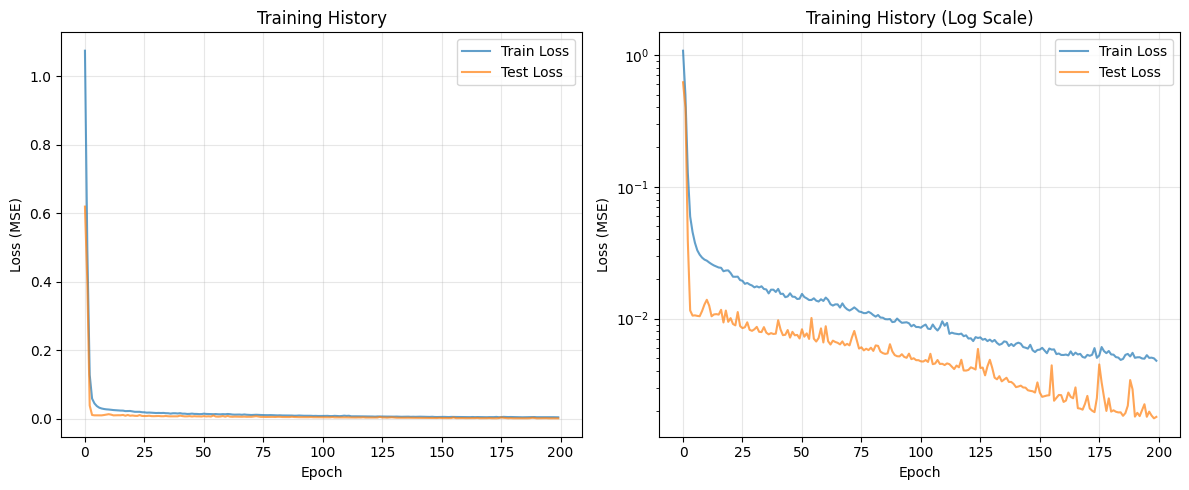


6. Saving model...
  Model saved to 'stock_predictor_model.pth'

COMPLETE!


In [23]:
# Step 5: Evaluate predictions
print("\n4. Evaluating predictions...")
normalization = data['normalization']
evaluate_predictions(
   model, 
   X_test, 
    y_test, 
    normalization['mean_y'], 
    normalization['std_y'],
    show_all=False  # Set to True to see all predictions
    )
    
# Step 6: Plot training history
print("\n5. Plotting training history...")
plot_training_history(train_losses, test_losses)
    
# Step 7: Save model
print("\n6. Saving model...")
checkpoint = {
    'model_state_dict': model.state_dict(),
    'struct': struct,
     'train_losses': train_losses,
    'test_losses': test_losses,
    'normalization': data['normalization'],
    'final_train_loss': train_losses[-1],
    'final_test_loss': test_losses[-1]
    }
    
torch.save(checkpoint, 'stock_predictor_model.pth')
print("  Model saved to 'stock_predictor_model.pth'")
    
print("\n" + "="*70)
print("COMPLETE!")
print("="*70)
    

Data shapes:
X_train: torch.Size([920, 60, 5])
y_train: torch.Size([920, 1])
X_test: torch.Size([230, 60, 5])
y_test: torch.Size([230, 1])

Model created with 3 layers

Training Configuration
Epoch [  1/500] Train Loss: 1.2193 Test Loss: 0.8472
Epoch [  2/500] Train Loss: 1.2096 Test Loss: 0.8457
Epoch [  3/500] Train Loss: 1.2068 Test Loss: 0.8443
Epoch [  4/500] Train Loss: 1.1986 Test Loss: 0.8432
Epoch [  5/500] Train Loss: 1.1926 Test Loss: 0.8419
Epoch [  6/500] Train Loss: 1.1908 Test Loss: 0.8407
Epoch [  7/500] Train Loss: 1.1766 Test Loss: 0.8393
Epoch [  8/500] Train Loss: 1.1740 Test Loss: 0.8380
Epoch [  9/500] Train Loss: 1.1711 Test Loss: 0.8366
Epoch [ 10/500] Train Loss: 1.1710 Test Loss: 0.8356
Epoch [ 11/500] Train Loss: 1.1664 Test Loss: 0.8341
Epoch [ 12/500] Train Loss: 1.1519 Test Loss: 0.8326
Epoch [ 13/500] Train Loss: 1.1504 Test Loss: 0.8313
Epoch [ 14/500] Train Loss: 1.1494 Test Loss: 0.8297
Epoch [ 15/500] Train Loss: 1.1449 Test Loss: 0.8284
Epoch [ 16/50

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
import pickle
import torch


def print_stock_data(filepath='stock_data/stock_data.pkl'):
    """Print contents of saved stock data file."""
    
    # Load the data
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    print("=" * 70)
    print("STOCK DATA FILE CONTENTS")
    print("=" * 70)
    
    # Print symbols
    print(f"\nStocks: {', '.join(data['symbols'])}")
    
    # Print shapes
    print(f"\nData Shapes:")
    print(f"  X (inputs):  {data['X'].shape}")
    print(f"  y (targets): {data['y'].shape}")
    
    # Print a sample
    print(f"\n{'='*70}")
    print("SAMPLE DATA (First Sequence)")
    print("=" * 70)
    
    X_sample = data['X'][0]
    y_sample = data['y'][0]
    
    # Denormalize
    if data['mean_X'] is not None:
        X_sample = X_sample * data['std_X'] + data['mean_X']
        y_sample = y_sample * data['std_y'] + data['mean_y']
    
    print(f"\nTarget Price: ${y_sample.item():.2f}")
    print(f"\nInput Sequence (60 days of OHLCV):")
    print("-" * 70)
    print(f"{'Day':>4} | {'Open':>10} | {'High':>10} | {'Low':>10} | {'Close':>10} | {'Volume':>12}")
    print("-" * 70)
    
    # Print first 10 days
    for i in range(min(10, len(X_sample))):
        open_p, high, low, close, volume = X_sample[i]
        print(f"{i+1:4d} | ${open_p:9.2f} | ${high:9.2f} | ${low:9.2f} | ${close:9.2f} | {volume:12.0f}")
    
    if len(X_sample) > 20:
        print("  ...")
        # Print last 10 days
        for i in range(len(X_sample) - 10, len(X_sample)):
            open_p, high, low, close, volume = X_sample[i]
            print(f"{i+1:4d} | ${open_p:9.2f} | ${high:9.2f} | ${low:9.2f} | ${close:9.2f} | {volume:12.0f}")
    elif len(X_sample) > 10:
        for i in range(10, len(X_sample)):
            open_p, high, low, close, volume = X_sample[i]
            print(f"{i+1:4d} | ${open_p:9.2f} | ${high:9.2f} | ${low:9.2f} | ${close:9.2f} | {volume:12.0f}")
    
    print("-" * 70)
    print(f"{'→':>4} | {'':>10} | {'':>10} | {'':>10} | ${y_sample.item():9.2f} | {'(Target)':>12}")
    print("=" * 70)
    
    # Print statistics
    print(f"\nNormalization Parameters:")
    if data['mean_X'] is not None:
        print(f"  mean_X: {data['mean_X']}")
        print(f"  std_X:  {data['std_X']}")
        print(f"  mean_y: {data['mean_y'].item():.2f}")
        print(f"  std_y:  {data['std_y'].item():.2f}")
    else:
        print("  Not normalized")
    
    print("\n" + "=" * 70)


# Usage
if __name__ == "__main__":
    print_stock_data('stock_data/stock_data.pkl')

STOCK DATA FILE CONTENTS

Stocks: AAPL, MSFT, GOOGL, TSLA, AMZN

Data Shapes:
  X (inputs):  torch.Size([1150, 60, 5])
  y (targets): torch.Size([1150, 1, 1])

SAMPLE DATA (First Sequence)

Target Price: $23935.33

Input Sequence (60 days of OHLCV):
----------------------------------------------------------------------
 Day |       Open |       High |        Low |      Close |       Volume
----------------------------------------------------------------------
   1 | $ 27852.04 | $ 28488.27 | $ 27525.91 | $ 28183.55 | 1760081355997184
   2 | $ 28081.23 | $ 28538.25 | $ 27303.49 | $ 27586.15 | 1945756281864192
   3 | $ 27567.76 | $ 28285.05 | $ 27232.62 | $ 27777.58 | 2086552154931200
   4 | $ 27627.26 | $ 28618.21 | $ 27079.98 | $ 28294.67 | 5054944042287104
   5 | $ 28368.83 | $ 28690.39 | $ 27926.06 | $ 28380.49 | 1400308722827264
   6 | $ 28448.17 | $ 28974.69 | $ 28126.68 | $ 28702.84 | 796297405661184
   7 | $ 28745.67 | $ 29184.57 | $ 28381.81 | $ 28793.05 | 933467252588544
   8 |